In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"E:\Data Science\machine learning\Project\Categorical\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv",sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data Understanding

In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

##### The dataset contains 41,188 records and 21 features, including both numerical and categorical variables. There are no actual NaN values, but missing information is encoded as the string "unknown" in several categorical features and should be identified and handled during data preprocessing.

## EDA

In [11]:
numerical_cols = df.select_dtypes(include= 'number').columns.tolist()
categorical_cols = df.drop(columns = ["y"]).select_dtypes(include= 'str').columns.tolist()

In [12]:
print("counts of numerical columns:", len(numerical_cols))
print("counts of categorical columns:", len(categorical_cols))

counts of numerical columns: 10
counts of categorical columns: 10


### Disguised Missing Values

In [72]:
unknown_counts = {}
for c in categorical_cols:
    cnt = (df[c] == 'unknown').sum()
    if cnt > 0:
        unknown_counts[c] = (cnt, round(cnt / len(df) * 100, 2))
unknown_df = pd.DataFrame(unknown_counts, index=['count', 'percent']).T.sort_values('count', ascending=False)
unknown_df

,count,percent
default,8597.0,20.87
education,1731.0,4.20
housing,990.0,2.40
loan,990.0,2.40
job,330.0,0.80
marital,80.0,0.19


### Target Distribution

     Counts    Percent
y                     
no    36548  88.734583
yes    4640  11.265417


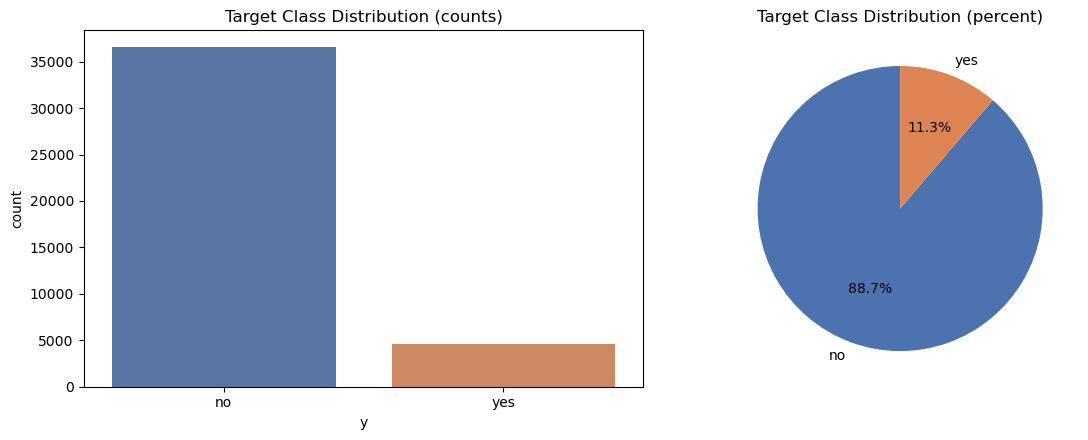

In [65]:
target_counts = df["y"].value_counts()
target_percent = df["y"].value_counts(normalize=True) * 100

target_table = pd.DataFrame({"Counts": target_counts,
                            "Percent": target_percent})
print(target_table)

fig , ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x=df["y"], data=df, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title("Target Class Distribution (counts)")

ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title("Target Class Distribution (percent)")
plt.tight_layout()
plt.show()

##### The target variable is highly imbalanced, with approximately 88.7% of observations belonging to the "no" class and only 11.3% to the "yes" class (roughly an 8:1 ratio).

### Numerical Columns

In [14]:
df[numerical_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


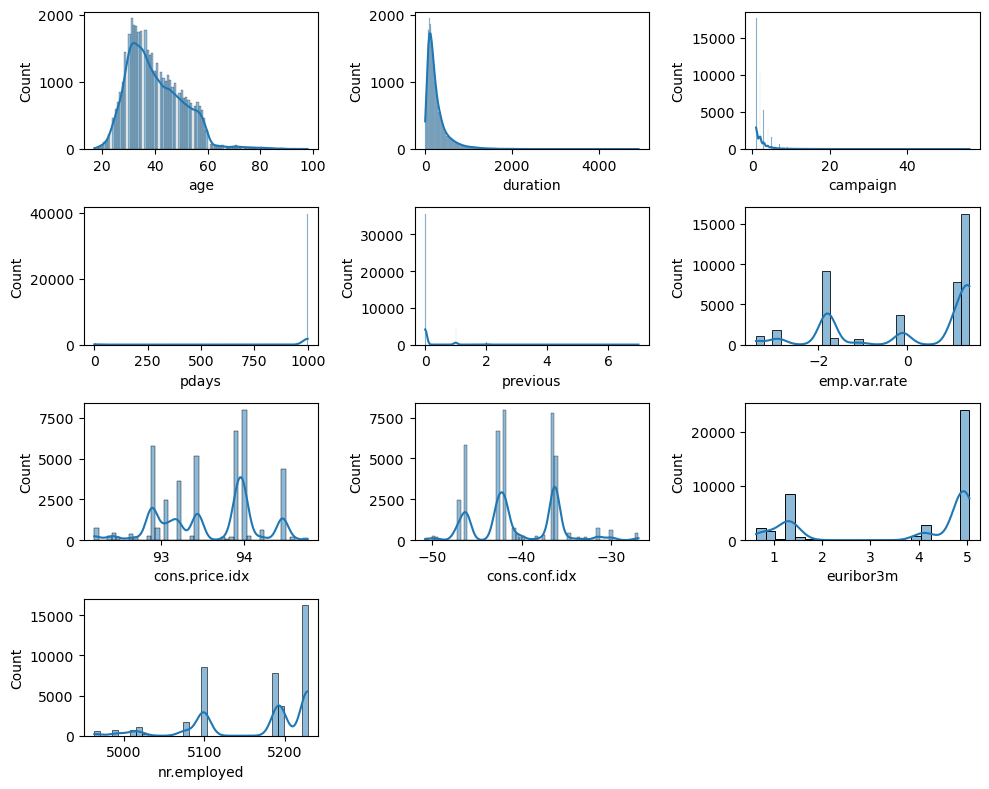

In [15]:
plt.figure(figsize = (10,8))
for idx,cols in enumerate(numerical_cols, start = 1):
    plt.subplot(4,3,idx)
    sns.histplot(df[cols], kde = True)

plt.tight_layout()
plt.show()

- age shows a roughly normal distribution with slight positive skewness. 
- duration, campaign, and previous are highly right-skewed, indicating the presence of outliers. 
- pdays is dominated by the sentinel value 999, resulting in a distorted distribution. 
- Macroeconomic variables exhibit multimodal patterns due to repeated time-based observations rather than continuous measurements."""

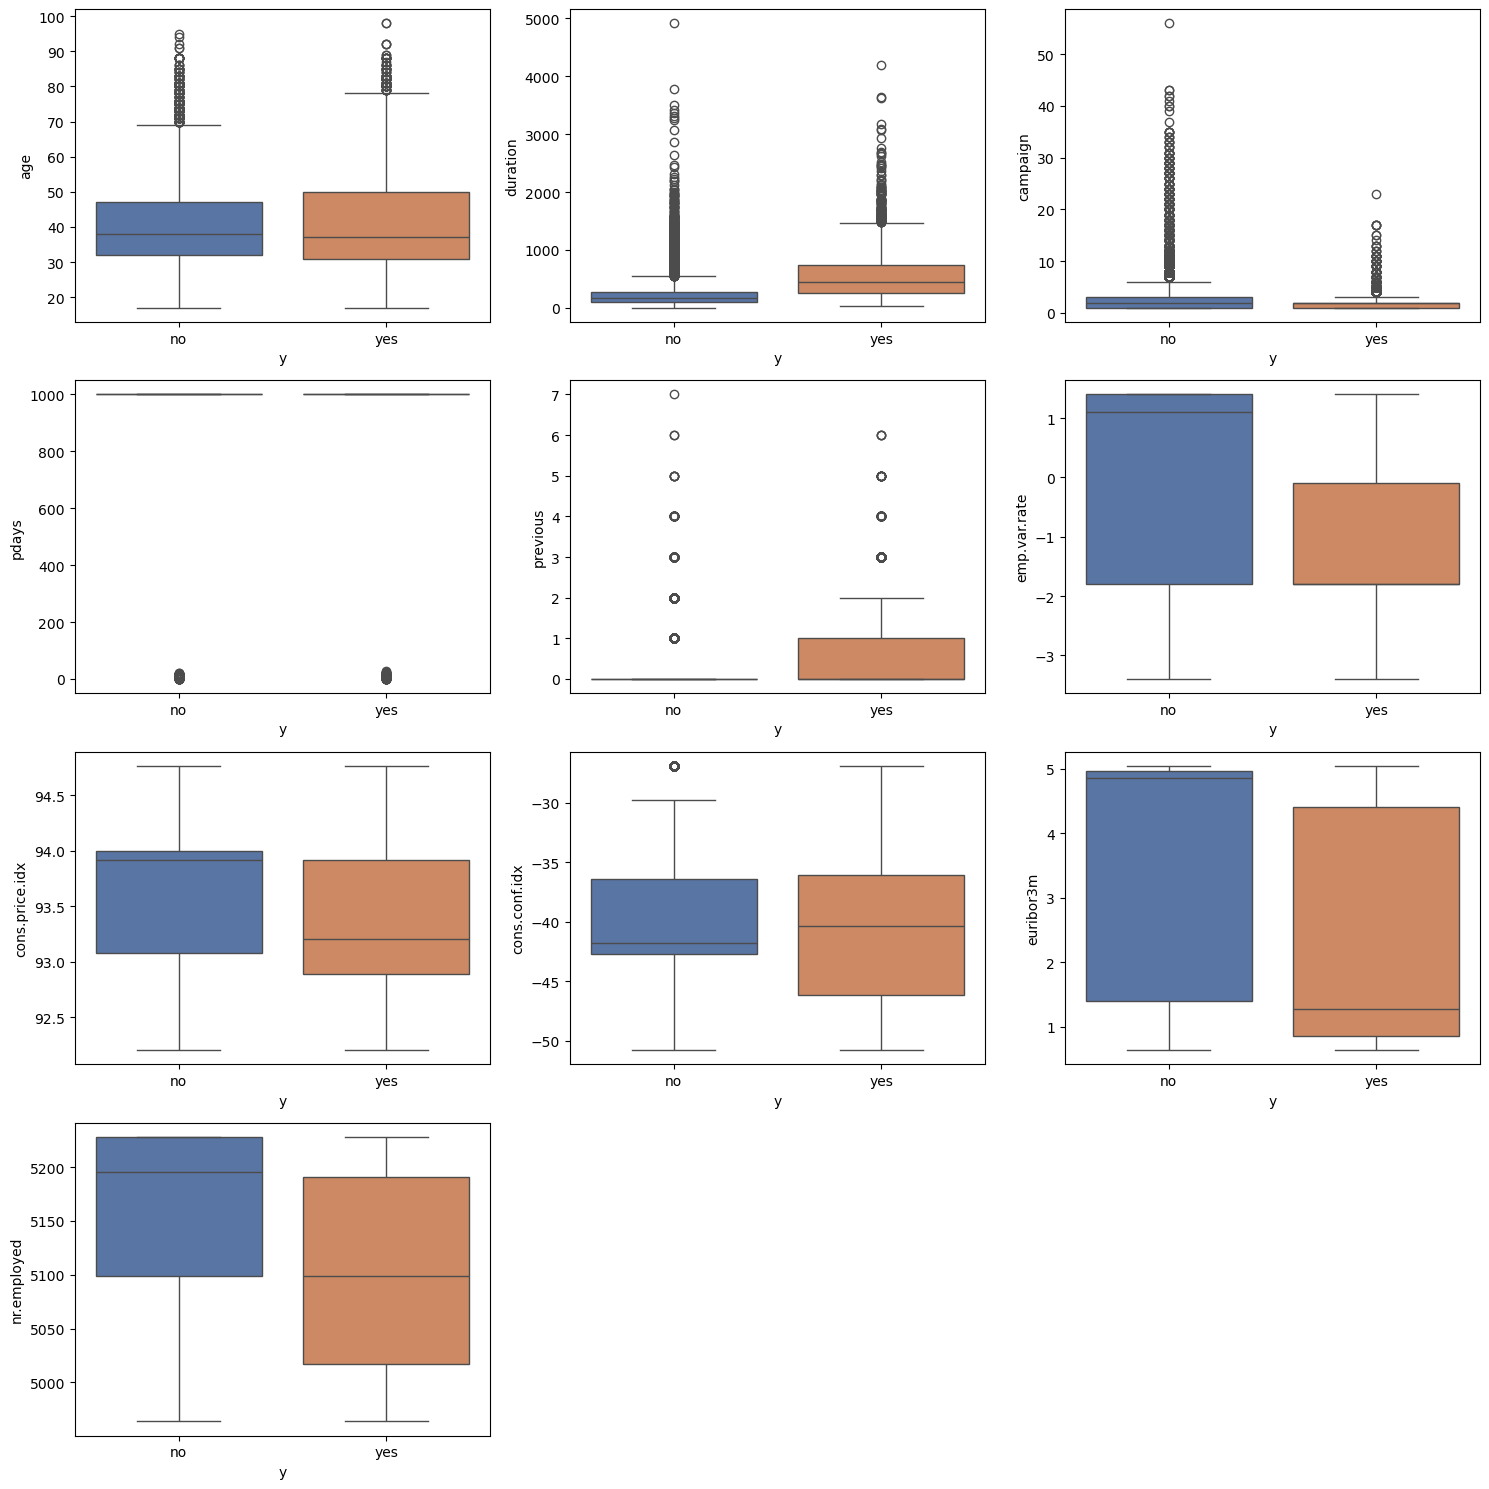

In [74]:
plt.figure(figsize = (15,15))
for i, col in enumerate(numerical_cols, start = 1):
    plt.subplot(4,3,i)
    sns.boxplot(x=df["y"], y=col, data=df, palette=['#4C72B0', '#DD8452'])
plt.tight_layout()
plt.show()

- duration provides the strongest class separation; longer calls are more likely to result in a yes outcome, although it should be excluded from modeling due to data leakage.
- age shows only a weak relationship with the target.
- campaign is negatively associated with subscription, as customers contacted fewer times tend to have higher conversion rates.
- pdays and previous indicate that customers with prior campaign interactions are more likely to subscribe.
- emp.var.rate, euribor3m, and nr.employed suggest higher subscription rates during weaker economic conditions.

<Axes: >

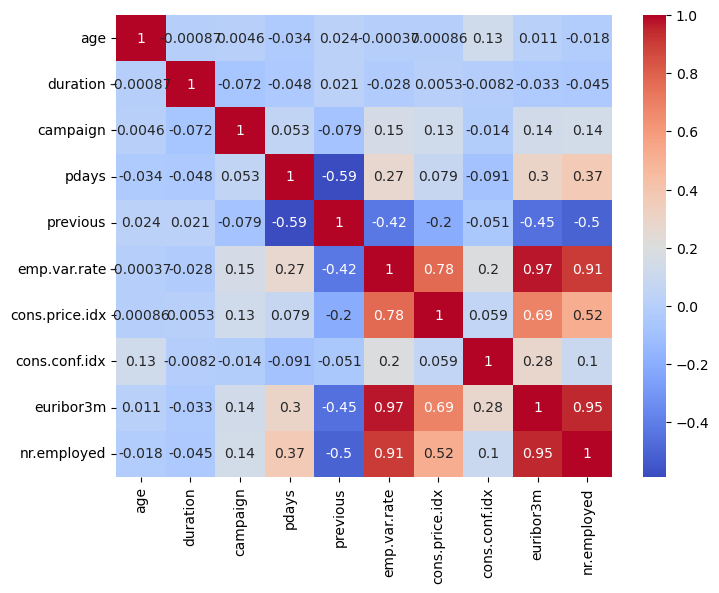

In [83]:
plt.figure(figsize = (8,6))
sns.heatmap(df[numerical_cols].corr(), annot = True, cmap = "coolwarm")

### Categorical Columns

In [68]:
df[categorical_cols].describe(include = "all")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563


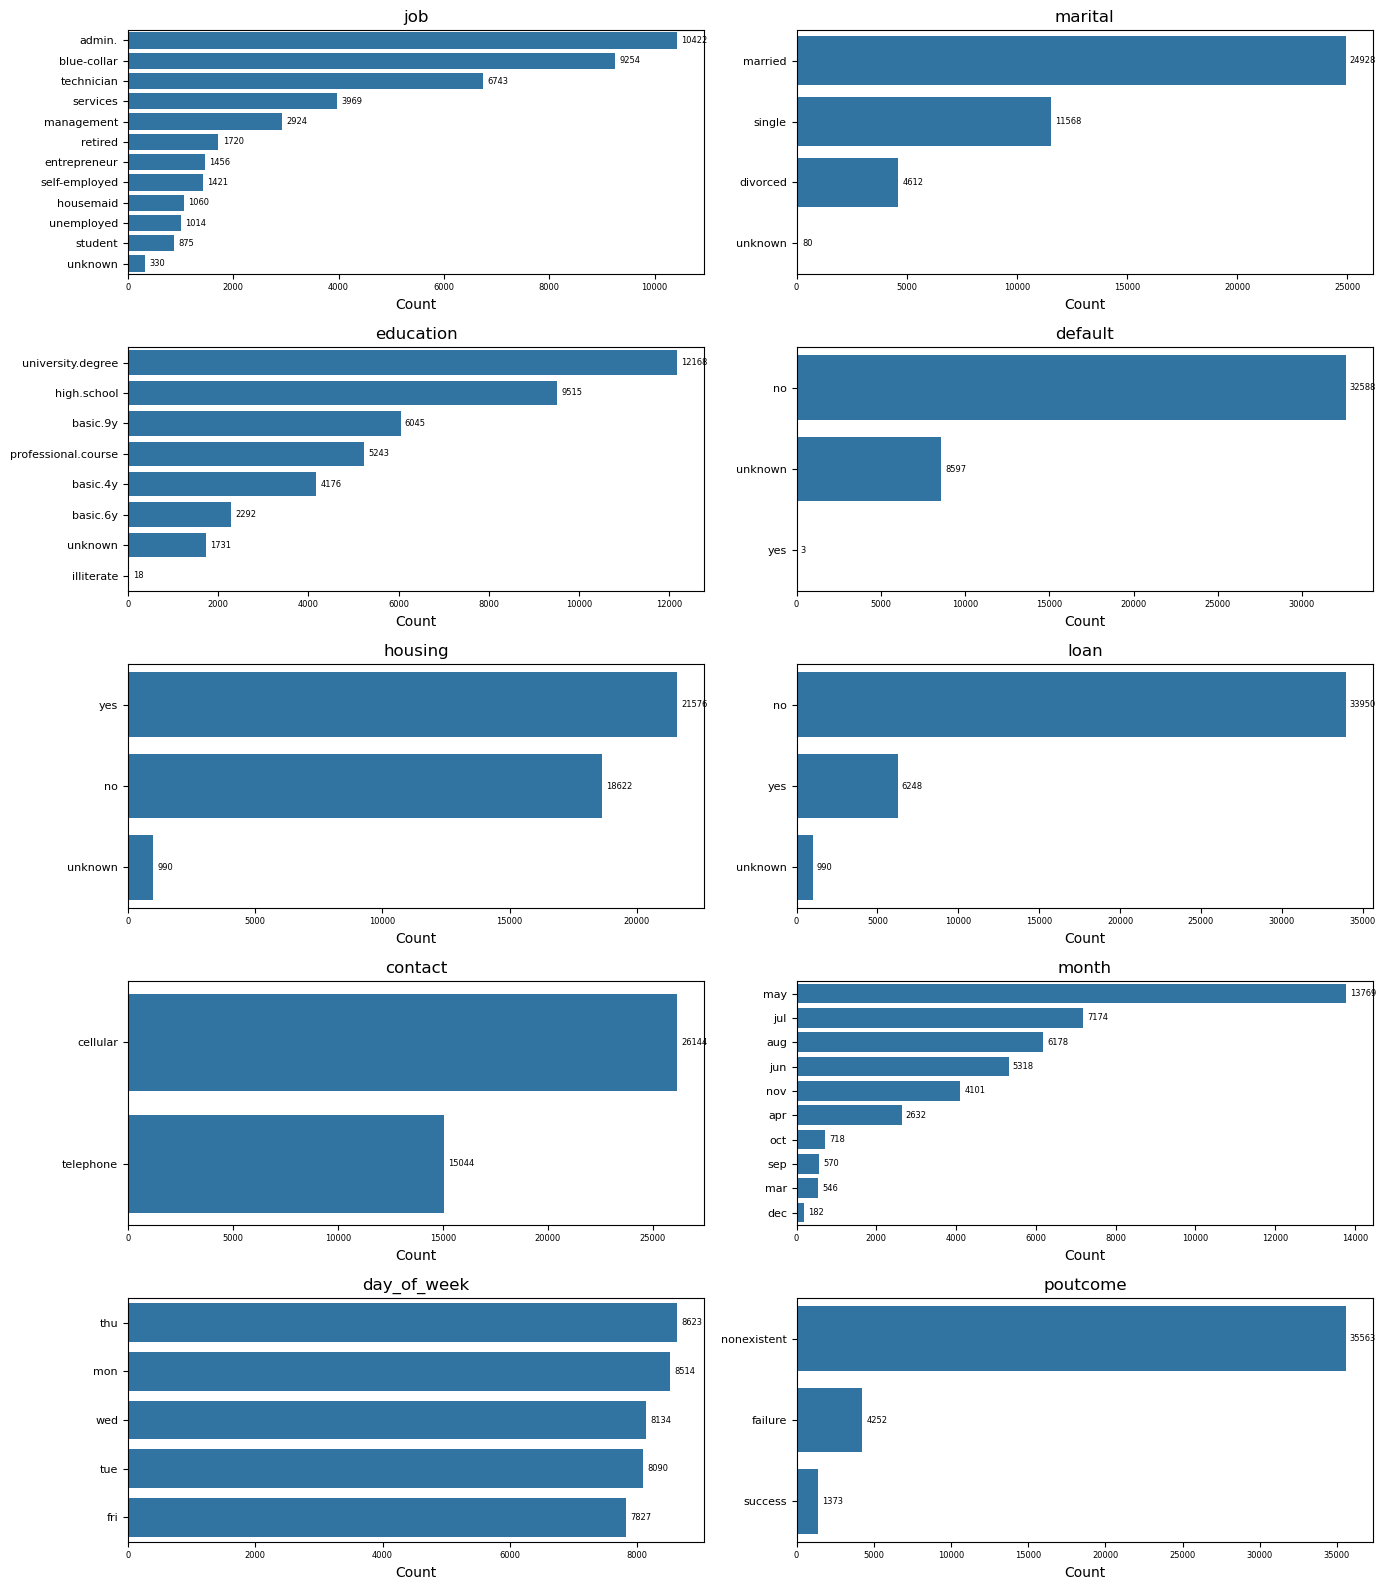

In [52]:
plt.figure(figsize=(14,16))
for idx, col in enumerate(categorical_cols, start=1):
    plt.subplot(5, 2, idx)

    counts = df[col].value_counts()

    ax = sns.barplot(
        x=counts.values,
        y=counts.index
    )

    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=6)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=6)
plt.tight_layout()
plt.show()

- admin and blue-collar are the most common occupations in the dataset. 
- Most customers are married, and the dominant education levels are university.
- degree and high.school Customer contacts were primarily conducted via cellular, with the highest contact volumes occurring in May, July, and August. 
- Additionally, the majority of customers have poutcome = nonexistent, indicating that they had no outcome from a previous marketing campaign.

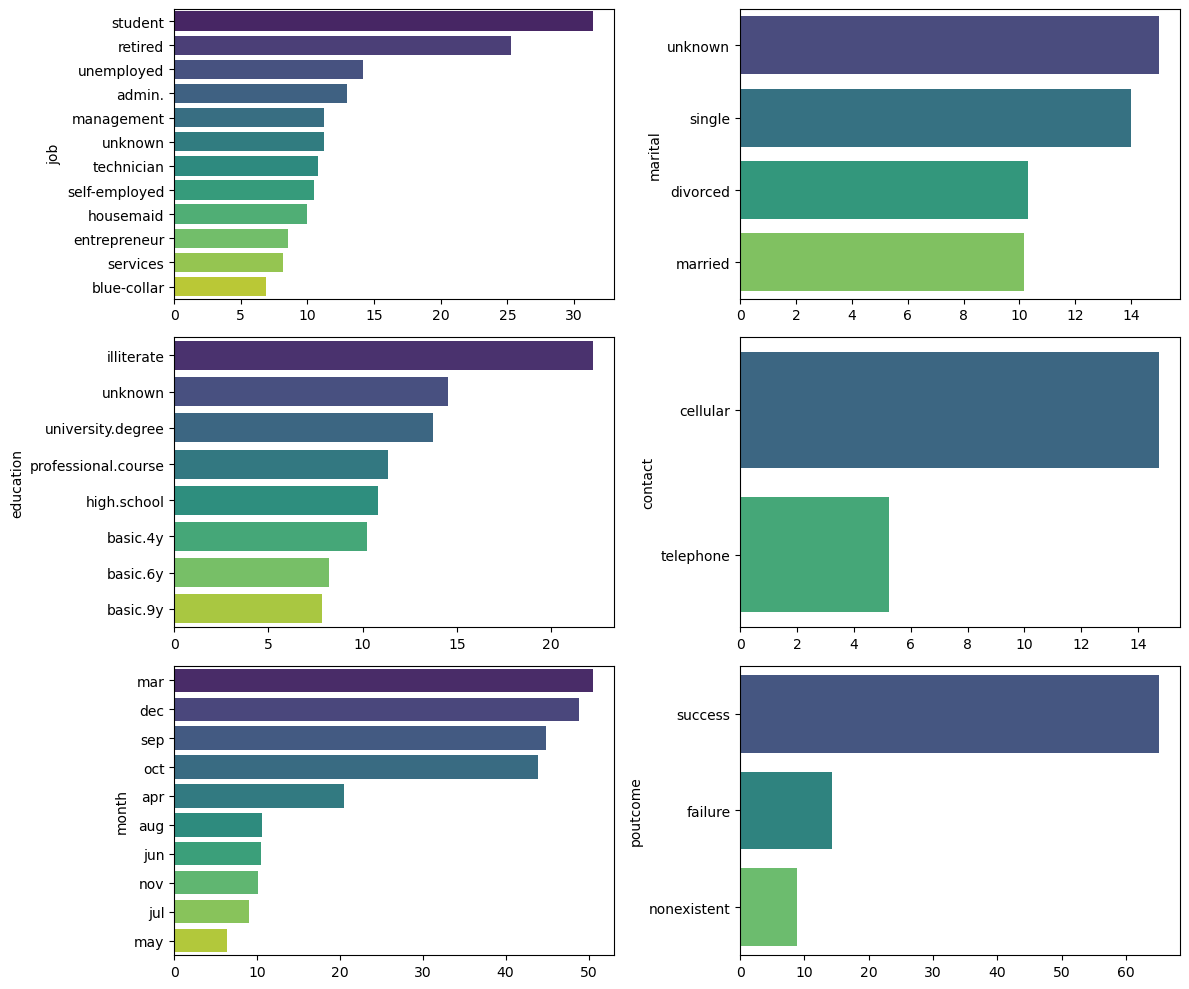

In [79]:
key_cats = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

plt.figure(figsize = (12,10))
for idx,col in enumerate(key_cats, start = 1):
    plt.subplot(3,2,idx)
    rate = df.groupby(col)["y"].apply(lambda s: (s == 'yes').mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, palette='viridis')
plt.tight_layout()
plt.show()

- job: Students and retirees have the highest conversion rates, while blue-collar workers and entrepreneurs show the lowest.
- education: Customers with a university.degree generally exhibit higher conversion rates; the high rate for illiterate should be interpreted cautiously due to its very small sample size.
- contact: cellular contacts achieve substantially higher conversion rates than telephone.
- month: Conversion rates are highest in March, September, October, and December, while May has the lowest, suggesting a seasonal effect.
- poutcome: Customers with a previous campaign outcome of success have by far the highest probability of subscribing, making it one of the strongest predictive features.

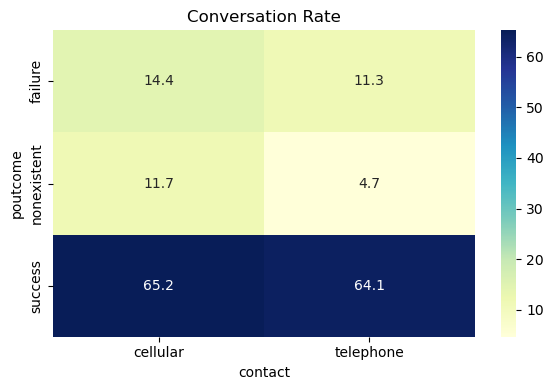

contact,cellular,telephone
poutcome,,
failure,14.448381,11.333333
nonexistent,11.729280,4.692302
success,65.196850,64.077670


In [86]:
pivot = df.pivot_table(index='poutcome', columns='contact', values= 'y',
                        aggfunc=lambda s: (s == 'yes').mean() * 100)
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Conversation Rate')
plt.tight_layout()
plt.show()
pivot


##### Customers with poutcome = success contacted via the cellular channel exhibit the highest conversion rate. This suggests a meaningful interaction between these two features, making their combination a strong candidate for feature engineering.

## Data Cleaning

In [96]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
df_clean.shape

(41176, 21)

In [97]:
cap_value = df_clean['campaign'].quantile(0.99)
n_capped = (df_clean['campaign'] > cap_value).sum()
df_clean['campaign'] = np.where(df_clean['campaign'] > cap_value, cap_value, df_clean['campaign'])

In [101]:
for c in categorical_cols:
    df_clean[c] = df_clean[c].astype('category')

df_clean["y"] = df_clean["y"].astype('category')

## Feature Engineering

In [104]:
df_feat = df_clean.copy()
df_feat = df_feat.drop(columns=['duration'])

In [105]:
# pdays
df_feat['was_contacted_before'] = (df_feat['pdays'] != 999).astype(int)
df_feat['pdays_clean'] = np.where(df_feat['pdays'] == 999, 0, df_feat['pdays'])
df_feat = df_feat.drop(columns=['pdays'])
print(df_feat[['was_contacted_before', 'pdays_clean']].describe())

       was_contacted_before   pdays_clean
count          41176.000000  41176.000000
mean               0.036793      0.221294
std                0.188256      1.349065
min                0.000000      0.000000
25%                0.000000      0.000000
50%                0.000000      0.000000
75%                0.000000      0.000000
max                1.000000     27.000000


In [106]:
# age
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_feat['age_group'] = pd.cut(df_feat['age'], bins=bins, labels=labels, include_lowest=True)
print(df_feat['age_group'].value_counts().sort_index())

age_group
18-25     1665
26-35    14844
36-45    12839
46-55     8247
56-65     2963
65+        618
Name: count, dtype: int64


In [108]:
# poutcome & contact
df_feat['poutcome_contact'] = (df_feat['poutcome'].astype(str) + '_' + df_feat['contact'].astype(str)).astype('category')
print(df_feat['poutcome_contact'].value_counts())

poutcome_contact
nonexistent_cellular     20913
nonexistent_telephone    14638
failure_cellular          3952
success_cellular          1270
failure_telephone          300
success_telephone          103
Name: count, dtype: int64


In [112]:
#education
edu_freq = df_feat['education'].value_counts(normalize=True)
rare_edu = edu_freq[edu_freq < 0.01].index.tolist()

df_feat['education'] = df_feat['education'].astype(str)
df_feat.loc[df_feat['education'].isin(rare_edu), 'education'] = 'other'
df_feat['education'] = df_feat['education'].astype('category')
print(df_feat['education'].value_counts())

education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
other                     18
Name: count, dtype: int64


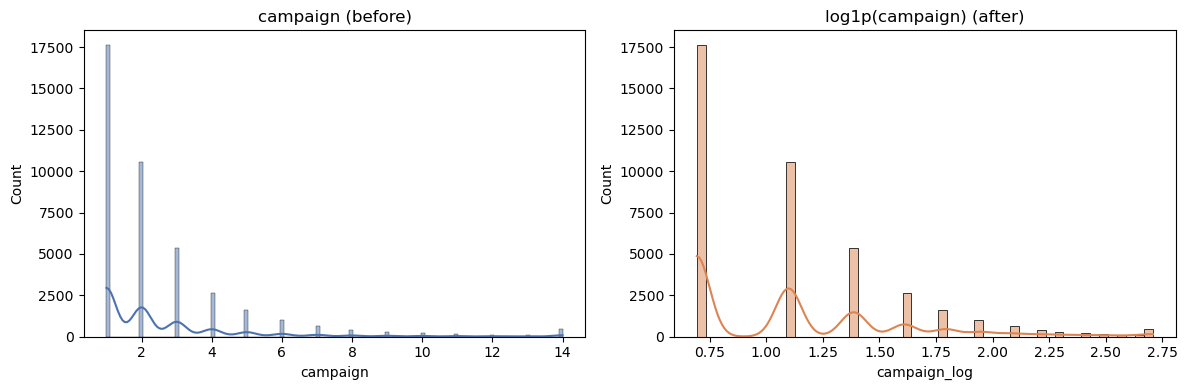

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_feat['campaign'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('campaign (before)')
df_feat['campaign_log'] = np.log1p(df_feat['campaign'])
sns.histplot(df_feat['campaign_log'], kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('log1p(campaign) (after)')
plt.tight_layout()
plt.show()

In [115]:
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_feat['month_num'] = df_feat['month'].astype(str).map(month_map)

In [116]:
df_feat.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before,pdays_clean,age_group,poutcome_contact,campaign_log,month_num
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1.0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,56-65,nonexistent_telephone,0.693147,5
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1.0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,56-65,nonexistent_telephone,0.693147,5
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1.0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,36-45,nonexistent_telephone,0.693147,5
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1.0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,36-45,nonexistent_telephone,0.693147,5
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1.0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,56-65,nonexistent_telephone,0.693147,5


## Exploratory Feature Analysis